In [10]:
import matplotlib.pyplot as plt
import pandas as pd

WIDTH_PT = 455.24411 * 0.75
WIDTH_IN = WIDTH_PT / 72.27
HEIGHT_IN = WIDTH_IN * 0.66

plt.rcParams.update({
    "font.size": 10,          # passend zu 10pt Fließtext
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

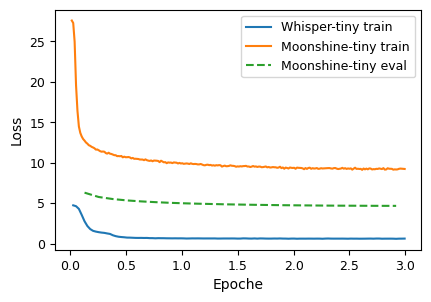

In [11]:
df = pd.read_json("../local_results/training_history_moonshine.json")
df_1 = pd.read_json("../local_results/training_history.json")

train_ms = df.dropna(subset=["loss"])
eval_ms = df.dropna(subset=["eval_loss"])
train_ws = df_1.dropna(subset=["loss"])
eval_ws = df_1.dropna(subset=["eval_loss"]) if "eval_loss" in df_1.columns else None

fig, ax = plt.subplots(figsize=(WIDTH_IN, HEIGHT_IN), dpi=100)

ax.plot(train_ws["epoch"], train_ws["loss"], label="Whisper-tiny train")
if eval_ws is not None and not eval_ws.empty:
    ax.plot(eval_ws["epoch"], eval_ws["eval_loss"], linestyle="--", label="Whisper-tiny eval")
ax.plot(train_ms["epoch"], train_ms["loss"], label="Moonshine-tiny train")
ax.plot(eval_ms["epoch"], eval_ms["eval_loss"], linestyle="--", label="Moonshine-tiny eval")
ax.legend()
plt.xlabel("Epoche")
plt.ylabel("Loss")

plt.savefig("../local_results/moonshine_history.png", dpi=600, bbox_inches="tight")